# Heart Disease Prediction

#### Problem Statement :

- Heart disease is one of the leading causes of global mortality. Early detection allows healthcare providers to implement timely clinical interventions.
- Traditional diagnostic methods rely on manual evaluation which can be time-consuming and subject to human error.
- The objective of this project is to build an automated bianry classification model using ANN to predict whether a patient has heart disease based on clinical features.

-------------------------------------------------------------

### 1. Import Libraries :

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded successfully.")

Libraries loaded successfully.


### 2. Load dataset :

In [2]:
df = pd.read_csv("heart-disease.csv")
print("Dataset loaded successfully.")

Dataset loaded successfully.


### 3. Dataset Description

In [3]:
print("Dataset preview :")
print(df.head())

print()

print("Dataset shape : ",df.shape)
print()

print("Dataset columns and its types :",df.dtypes)
print()

df.columns

Dataset preview :
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  

Dataset shape :  (303, 14)

Dataset columns and its types : age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object



Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

In [4]:
print("Dataset Summary Statistics :\n",df.describe())

Dataset Summary Statistics :
               age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.366337    0.683168    0.966997  131.623762  246.264026    0.148515   
std      9.082101    0.466011    1.032052   17.538143   51.830751    0.356198   
min     29.000000    0.000000    0.000000   94.000000  126.000000    0.000000   
25%     47.500000    0.000000    0.000000  120.000000  211.000000    0.000000   
50%     55.000000    1.000000    1.000000  130.000000  240.000000    0.000000   
75%     61.000000    1.000000    2.000000  140.000000  274.500000    0.000000   
max     77.000000    1.000000    3.000000  200.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean     0.528053  149.646865    0.326733    1.039604    1.399340    0.729373 

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


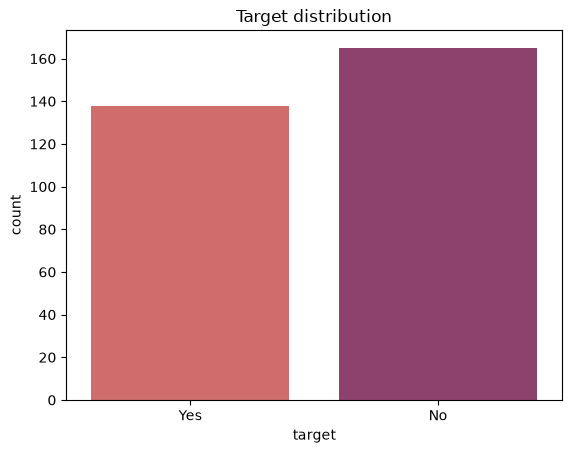

target
1    54.455446
0    45.544554
Name: proportion, dtype: float64


In [6]:
# distribution of target

sns.countplot(x='target', data=df, palette="flare")
plt.xticks(ticks=[0,1], labels =["Yes", "No"])
plt.title("Target distribution")
plt.show()

target_percentage = df['target'].value_counts(normalize=True)*100
print(target_percentage)

### 4. Data Preprocessing

In [7]:
#missing values
print("Missing values in each columns:")
print(df.isnull().sum())
print()

#duplication
print("Duplication :\n", df.duplicated())

Missing values in each columns:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Duplication :
 0      False
1      False
2      False
3      False
4      False
       ...  
298    False
299    False
300    False
301    False
302    False
Length: 303, dtype: bool


### 5. Feature Scaling & Train-test split

In [8]:
# separate features (X) and target(y)
X = df.drop("target", axis=1)
y = df["target"]

print("Features shape :", X.shape)
print("Target shape :", y.shape)

Features shape : (303, 13)
Target shape : (303,)


In [9]:
# Splitting the dataset into training and testing
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set :", X_train.shape)
print("Training set :", y_train.shape)

print()

print("Testing set :", X_test.shape)
print("Testing set :", y_test.shape)

print()

print(y_train.value_counts())

print()

y_train.head()

Training set : (242, 13)
Training set : (242,)

Testing set : (61, 13)
Testing set : (61,)

target
1    132
0    110
Name: count, dtype: int64



19     1
247    0
289    0
288    0
60     1
Name: target, dtype: int64

In [10]:
# feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {X_train_scaled.shape[0]}")
print(f"Testing samples: {X_test_scaled.shape[0]}") 


Training samples: 242
Testing samples: 61


### 6. ANN Model & Training

In [11]:
# build ANN model
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

# compile the model
model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

print("working....")

working....


In [ ]:
# train model
history = model.fit(
    X_train_scaled, 
    y_train,
    epochs=60,
    batch_size=16,
    validation_split=0.15,
    verbose=1
)

Epoch 1/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.5512 - loss: 0.6581 - val_accuracy: 0.5135 - val_loss: 0.6428
Epoch 2/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6049 - loss: 0.6261 - val_accuracy: 0.7568 - val_loss: 0.5797
Epoch 3/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7317 - loss: 0.5603 - val_accuracy: 0.8378 - val_loss: 0.5263
Epoch 4/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7512 - loss: 0.5331 - val_accuracy: 0.8649 - val_loss: 0.4794
Epoch 5/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7707 - loss: 0.5206 - val_accuracy: 0.8649 - val_loss: 0.4380
Epoch 6/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7902 - loss: 0.4954 - val_accuracy: 0.8919 - val_loss: 0.4034
Epoch 7/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8439 - loss: 0.4451 - val_accuracy: 0.8919 - val_loss: 0.3739
Epoch 8/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8488 - loss: 0.4309 - val_accuracy: 0.8919 - v

### 7. Validation Graphs & Accuracy/Loss Analysis

In [ ]:
loss, accuracy = model.evaluate(X_test_scaled, y_test)

print(f"The model is {accuracy*100:.2f} % accurate")
print(f"The model is {loss:.2f} loss")

In [ ]:
plt.figure(figsize=(12, 4))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
plt.title('ANN Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
plt.title('ANN Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_graphs.png')
plt.show()

### 8. Confusion Matrix & Classification Report

In [ ]:
from sklearn.metrics import(
confusion_matrix,
classification_report,
accuracy_score
)
y_pred_probs = model.predict(X_test_scaled)
y_pred = (y_pred_probs>0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix: ")
print(cm)
print()


In [ ]:
# heatmap for confusion matrix
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Heart Disease"],
    yticklabels=["No Disease", "Heart Disease"],
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix")
plt.show()

In [ ]:
#precision, recall & f1-score
print("\nClassification Report:\n")
print(classification_report(y_test,y_pred,target_names=['No Disease (0)', 'Heart Disease (1)']))


### 9. Prediction on new sample

In [ ]:
print("\n------ Enter Patient Details ------\n")
age = float(input("Age: "))
sex = float(input("Sex (1=Male, 0=Female): "))
cp = float(input("Chest Pain Type (0-3): "))
trestbps = float(input("Resting Blood Pressure (80-220): "))
chol = float(input("Cholesterol (100-600): "))
fbs = float(input("Fasting Blood Sugar > 120 (1=True, 0=False): "))
restecg = float(input("Resting ECG (0-2): "))
thalach = float(input("Max Heart Rate (60-220): "))
exang = float(input("Exercise Induced Angina (1=Yes, 0=No): "))
oldpeak = float(input("ST Depression(oldpeak) (0.0-6.5): "))
slope = float(input("Slope (0-2): "))
ca = float(input("Major Vessels Colored (0-4): "))
thal = float(input("Thal (1-3): "))

user_patient = pd.DataFrame([[age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal]])

user_scaled = scaler.transform(user_patient)
prob = model.predict(user_scaled)[0][0]

print("\n----New Patient Diagnosis Result----\n")
print(f"\nPredicted Heart Disease Probability: {prob * 100:.2f}%")
if prob >= 0.5:
    print("Diagnosis : Heart Disease Detected")
else:
    print("Diagnosis : No Heart Disease")

### 10. Conclusion

- In this project, the ANN model was built to predict heart disease prediction
- The model was trained using 13 clinical factors like age, blood pressure, resting ECG and other health indicators
- Raw data was preprocessed using StandardScaler to bring numeric inputs to a single scale
- Dropout layer was added after first hidden layer to randomly deactivate 20% of neurons during training which reduces model overfitting
- Model's performance was checked using Confusion matrix along with accuracy, precision and recall scores
- New patient inputs were fed into the model to generate instant diagnostic predictions.

In [ ]:
# save model
# model.save("heart_disease_prediction.h5")
print("Model saved successfully.")